# Few-Shot Prompting Experiment

# Cell 1 — Imports and load data

In [1]:
import requests
import json
import re
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

df = pd.read_csv("headlines_raw.csv")
print(f"Total headlines: {len(df)}")
print(df['label'].value_counts())
print(df['source'].value_counts())
headlines = df['headline'].tolist()

Total headlines: 14308
label
neutral     8990
positive    3273
negative    2045
Name: count, dtype: int64
source
twitter       9479
phrasebank    4829
Name: count, dtype: int64


# Cell 2 — Few-shot example banks

In [2]:
EXAMPLES_5SHOT = [
    {
        "headline": "Company reports record quarterly profit, beating analyst expectations by 15 percent.",
        "label": "positive",
        "json": '{"positive": 0.90, "negative": 0.05, "neutral": 0.05}'
    },
    {
        "headline": "Firm announces 2,000 layoffs and plant closures amid falling demand.",
        "label": "negative",
        "json": '{"positive": 0.05, "negative": 0.88, "neutral": 0.07}'
    },
    {
        "headline": "The company will publish its annual results on Thursday.",
        "label": "neutral",
        "json": '{"positive": 0.08, "negative": 0.08, "neutral": 0.84}'
    },
    {
        "headline": "Shares rose sharply after the firm raised its full-year earnings guidance.",
        "label": "positive",
        "json": '{"positive": 0.88, "negative": 0.04, "neutral": 0.08}'
    },
    {
        "headline": "Revenue declined 18 percent year-on-year due to supply chain disruptions.",
        "label": "negative",
        "json": '{"positive": 0.04, "negative": 0.90, "neutral": 0.06}'
    },
]

EXAMPLES_2SHOT = EXAMPLES_5SHOT[:2]

print("5-shot examples defined:", len(EXAMPLES_5SHOT))
print("2-shot examples defined:", len(EXAMPLES_2SHOT))

5-shot examples defined: 5
2-shot examples defined: 2


# Cell 3 — Prompt builder functions

In [3]:
def build_fewshot_prompt(headline: str, examples: list) -> str:
    prompt = "Analyze the financial sentiment of news headlines.\n"
    prompt += "Respond with ONLY a JSON object: {\"positive\": float, \"negative\": float, \"neutral\": float}\n"
    prompt += "All three values must sum to 1.0. No explanation, just the JSON.\n\n"
    
    prompt += "Examples:\n"
    for ex in examples:
        prompt += f"Headline: {ex['headline']}\n"
        prompt += f"Output: {ex['json']}\n\n"
    
    prompt += f"Headline: {headline}\n"
    prompt += "Output:"
    return prompt


def parse_json_sentiment(text: str) -> dict:
    default = {"positive": 0.33, "negative": 0.33, "neutral": 0.34}
    try:
        match = re.search(r'\{[^{}]+\}', text)
        if match:
            result = json.loads(match.group())
            if all(k in result for k in ['positive', 'negative', 'neutral']):
                total = sum(result.values())
                if total > 0:
                    result = {k: v/total for k, v in result.items()}
                return result
    except Exception:
        pass
    return default


def get_ollama_fewshot(headline: str, model: str, examples: list) -> dict:
    prompt = build_fewshot_prompt(headline, examples)
    try:
        r = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": model, "prompt": prompt, "stream": False,
                  "options": {"temperature": 0.1, "num_predict": 60}},
            timeout=60
        )
        text = r.json().get("response", "")
        return parse_json_sentiment(text)
    except Exception:
        return {"positive": 0.33, "negative": 0.33, "neutral": 0.34}


test = headlines[0]
print("Test headline:", test)
print("\n2-shot prompt preview:")
print(build_fewshot_prompt(test, EXAMPLES_2SHOT))

Test headline: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

2-shot prompt preview:
Analyze the financial sentiment of news headlines.
Respond with ONLY a JSON object: {"positive": float, "negative": float, "neutral": float}
All three values must sum to 1.0. No explanation, just the JSON.

Examples:
Headline: Company reports record quarterly profit, beating analyst expectations by 15 percent.
Output: {"positive": 0.90, "negative": 0.05, "neutral": 0.05}

Headline: Firm announces 2,000 layoffs and plant closures amid falling demand.
Output: {"positive": 0.05, "negative": 0.88, "neutral": 0.07}

Headline: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Output:


# Cell 4 — Run Mistral 2-shot

In [4]:
SAVE_PATH_M2 = "fewshot_mistral_2shot.csv"

if os.path.exists(SAVE_PATH_M2):
    done_m2 = pd.read_csv(SAVE_PATH_M2)
    start_idx = len(done_m2)
    results_m2 = done_m2.to_dict('records')
    print(f"Resuming Mistral 2-shot from index {start_idx}")
else:
    results_m2 = []
    start_idx = 0

for i, h in enumerate(tqdm(headlines[start_idx:], desc="Mistral 2-shot"), start=start_idx):
    s = get_ollama_fewshot(h, "mistral", EXAMPLES_2SHOT)
    results_m2.append({
        "mistral_2shot_positive": s["positive"],
        "mistral_2shot_negative": s["negative"],
        "mistral_2shot_neutral":  s["neutral"]
    })
    if (i + 1) % 100 == 0:
        pd.DataFrame(results_m2).to_csv(SAVE_PATH_M2, index=False)

pd.DataFrame(results_m2).to_csv(SAVE_PATH_M2, index=False)
print(f"Mistral 2-shot done. Saved to {SAVE_PATH_M2}")

Mistral 2-shot: 100%|███████████████████████████████████████████████████████████| 14308/14308 [2:16:12<00:00,  1.75it/s]

Mistral 2-shot done. Saved to fewshot_mistral_2shot.csv


# Cell 5 — Run Mistral 5-shot

In [5]:
SAVE_PATH_M5 = "fewshot_mistral_5shot.csv"

if os.path.exists(SAVE_PATH_M5):
    done_m5 = pd.read_csv(SAVE_PATH_M5)
    start_idx = len(done_m5)
    results_m5 = done_m5.to_dict('records')
    print(f"Resuming Mistral 5-shot from index {start_idx}")
else:
    results_m5 = []
    start_idx = 0

for i, h in enumerate(tqdm(headlines[start_idx:], desc="Mistral 5-shot"), start=start_idx):
    s = get_ollama_fewshot(h, "mistral", EXAMPLES_5SHOT)
    results_m5.append({
        "mistral_5shot_positive": s["positive"],
        "mistral_5shot_negative": s["negative"],
        "mistral_5shot_neutral":  s["neutral"]
    })
    if (i + 1) % 100 == 0:
        pd.DataFrame(results_m5).to_csv(SAVE_PATH_M5, index=False)

pd.DataFrame(results_m5).to_csv(SAVE_PATH_M5, index=False)
print(f"Mistral 5-shot done. Saved to {SAVE_PATH_M5}")

Mistral 5-shot: 100%|███████████████████████████████████████████████████████████| 14308/14308 [2:18:33<00:00,  1.72it/s]

Mistral 5-shot done. Saved to fewshot_mistral_5shot.csv


# Cell 6 — Run Llama3 2-shot

In [6]:
SAVE_PATH_L2 = "fewshot_llama3_2shot.csv"

if os.path.exists(SAVE_PATH_L2):
    done_l2 = pd.read_csv(SAVE_PATH_L2)
    start_idx = len(done_l2)
    results_l2 = done_l2.to_dict('records')
    print(f"Resuming Llama3 2-shot from index {start_idx}")
else:
    results_l2 = []
    start_idx = 0

for i, h in enumerate(tqdm(headlines[start_idx:], desc="Llama3 2-shot"), start=start_idx):
    s = get_ollama_fewshot(h, "llama3", EXAMPLES_2SHOT)
    results_l2.append({
        "llama3_2shot_positive": s["positive"],
        "llama3_2shot_negative": s["negative"],
        "llama3_2shot_neutral":  s["neutral"]
    })
    if (i + 1) % 100 == 0:
        pd.DataFrame(results_l2).to_csv(SAVE_PATH_L2, index=False)

pd.DataFrame(results_l2).to_csv(SAVE_PATH_L2, index=False)
print(f"Llama3 2-shot done. Saved to {SAVE_PATH_L2}")

Llama3 2-shot: 100%|████████████████████████████████████████████████████████████| 14308/14308 [2:19:21<00:00,  1.71it/s]

Llama3 2-shot done. Saved to fewshot_llama3_2shot.csv


# Cell 7 — Run Llama3 5-shot

In [7]:
SAVE_PATH_L5 = "fewshot_llama3_5shot.csv"

if os.path.exists(SAVE_PATH_L5):
    done_l5 = pd.read_csv(SAVE_PATH_L5)
    start_idx = len(done_l5)
    results_l5 = done_l5.to_dict('records')
    print(f"Resuming Llama3 5-shot from index {start_idx}")
else:
    results_l5 = []
    start_idx = 0

for i, h in enumerate(tqdm(headlines[start_idx:], desc="Llama3 5-shot"), start=start_idx):
    s = get_ollama_fewshot(h, "llama3", EXAMPLES_5SHOT)
    results_l5.append({
        "llama3_5shot_positive": s["positive"],
        "llama3_5shot_negative": s["negative"],
        "llama3_5shot_neutral":  s["neutral"]
    })
    if (i + 1) % 100 == 0:
        pd.DataFrame(results_l5).to_csv(SAVE_PATH_L5, index=False)

pd.DataFrame(results_l5).to_csv(SAVE_PATH_L5, index=False)
print(f"Llama3 5-shot done. Saved to {SAVE_PATH_L5}")

Llama3 5-shot: 100%|████████████████████████████████████████████████████████████| 14308/14308 [2:20:29<00:00,  1.70it/s]

Llama3 5-shot done. Saved to fewshot_llama3_5shot.csv


# Cell 8 — All results into one DataFrame

In [8]:
import pandas as pd
import numpy as np

df_base   = pd.read_csv("headlines_raw.csv")          
df_zshot  = pd.read_csv("sentiment_all.csv")          
df_m2     = pd.read_csv("fewshot_mistral_2shot.csv")
df_m5     = pd.read_csv("fewshot_mistral_5shot.csv")
df_l2     = pd.read_csv("fewshot_llama3_2shot.csv")
df_l5     = pd.read_csv("fewshot_llama3_5shot.csv")

zshot_cols = ["finbert_positive","finbert_negative","finbert_neutral",
              "mistral_positive","mistral_negative","mistral_neutral",
              "llama3_positive","llama3_negative","llama3_neutral"]
df_zshot_trimmed = df_zshot[zshot_cols].reset_index(drop=True)

df_all = pd.concat([
    df_base.reset_index(drop=True),
    df_zshot_trimmed,
    df_m2.reset_index(drop=True),
    df_m5.reset_index(drop=True),
    df_l2.reset_index(drop=True),
    df_l5.reset_index(drop=True)
], axis=1)

df_all.to_csv("fewshot_results.csv", index=False)
print(f"Merged shape: {df_all.shape}")
print(df_all.columns.tolist())

Merged shape: (14308, 24)
['label', 'headline', 'source', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'mistral_positive', 'mistral_negative', 'mistral_neutral', 'llama3_positive', 'llama3_negative', 'llama3_neutral', 'mistral_2shot_positive', 'mistral_2shot_negative', 'mistral_2shot_neutral', 'mistral_5shot_positive', 'mistral_5shot_negative', 'mistral_5shot_neutral', 'llama3_2shot_positive', 'llama3_2shot_negative', 'llama3_2shot_neutral', 'llama3_5shot_positive', 'llama3_5shot_negative', 'llama3_5shot_neutral']


# Cell 9 — Evaluate all conditions

In [9]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv("fewshot_results.csv")

def probs_to_label(row, prefix):
    scores = {
        "positive": row[f"{prefix}_positive"],
        "negative": row[f"{prefix}_negative"],
        "neutral":  row[f"{prefix}_neutral"]
    }
    return max(scores, key=scores.get)

conditions = [
    ("FinBERT (zero-shot)",   "finbert"),
    ("Mistral-7B (zero-shot)","mistral"),
    ("Mistral-7B (2-shot)",   "mistral_2shot"),
    ("Mistral-7B (5-shot)",   "mistral_5shot"),
    ("Llama3-8B (zero-shot)", "llama3"),
    ("Llama3-8B (2-shot)",    "llama3_2shot"),
    ("Llama3-8B (5-shot)",    "llama3_5shot"),
]

true_labels = df["label"].tolist()

results = []
for name, prefix in conditions:
    pred = df.apply(lambda r: probs_to_label(r, prefix), axis=1).tolist()
    acc  = accuracy_score(true_labels, pred)
    f1m  = f1_score(true_labels, pred, average='macro',    labels=["positive","negative","neutral"])
    f1w  = f1_score(true_labels, pred, average='weighted', labels=["positive","negative","neutral"])
    
    pb_mask = df["source"] == "phrasebank"
    tw_mask = df["source"] == "twitter"
    acc_pb = accuracy_score(df.loc[pb_mask,"label"], [p for p,m in zip(pred,pb_mask) if m])
    acc_tw = accuracy_score(df.loc[tw_mask,"label"], [p for p,m in zip(pred,tw_mask) if m])
    
    results.append({
        "Model": name, "Accuracy": acc, "F1_macro": f1m,
        "F1_weighted": f1w, "Acc_PhraseBank": acc_pb, "Acc_Twitter": acc_tw
    })
    df[f"{prefix}_pred"] = pred

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
df_results.to_csv("fewshot_evaluation.csv", index=False)

                 Model  Accuracy  F1_macro  F1_weighted  Acc_PhraseBank  Acc_Twitter
   FinBERT (zero-shot)  0.771247  0.737343     0.776921        0.889004     0.711256
Mistral-7B (zero-shot)  0.534736  0.541879     0.514800        0.647132     0.477477
   Mistral-7B (2-shot)  0.417878  0.449311     0.330934        0.468420     0.392130
   Mistral-7B (5-shot)  0.414453  0.435383     0.318084        0.457238     0.392657
 Llama3-8B (zero-shot)  0.350224  0.376814     0.200333        0.393249     0.328305
    Llama3-8B (2-shot)  0.437308  0.447663     0.360728        0.556016     0.376833
    Llama3-8B (5-shot)  0.531940  0.538560     0.515005        0.698488     0.447094


# Cell 10 — Neutral class bias: does few-shot fix Llama3?

In [10]:
neutral_df = df[df["label"] == "neutral"]
n = len(neutral_df)
print(f"Truly neutral headlines: {n}\n")

llama_conditions = [
    ("Llama3 zero-shot", "llama3_pred"),
    ("Llama3 2-shot",    "llama3_2shot_pred"),
    ("Llama3 5-shot",    "llama3_5shot_pred"),
]
mistral_conditions = [
    ("Mistral zero-shot", "mistral_pred"),
    ("Mistral 2-shot",    "mistral_2shot_pred"),
    ("Mistral 5-shot",    "mistral_5shot_pred"),
]

print("=== LLAMA3 NEUTRAL PREDICTION DISTRIBUTION ===")
for name, col in llama_conditions:
    counts = neutral_df[col].value_counts(normalize=True) * 100
    neg = counts.get("negative", 0)
    neu = counts.get("neutral",  0)
    pos = counts.get("positive", 0)
    print(f"{name:25s} | Neg: {neg:.1f}%  Neu: {neu:.1f}%  Pos: {pos:.1f}%")

print("\n=== MISTRAL NEUTRAL PREDICTION DISTRIBUTION ===")
for name, col in mistral_conditions:
    counts = neutral_df[col].value_counts(normalize=True) * 100
    neg = counts.get("negative", 0)
    neu = counts.get("neutral",  0)
    pos = counts.get("positive", 0)
    print(f"{name:25s} | Neg: {neg:.1f}%  Neu: {neu:.1f}%  Pos: {pos:.1f}%")

Truly neutral headlines: 8990

=== LLAMA3 NEUTRAL PREDICTION DISTRIBUTION ===
Llama3 zero-shot          | Neg: 15.1%  Neu: 0.0%  Pos: 84.8%
Llama3 2-shot             | Neg: 30.8%  Neu: 14.6%  Pos: 54.5%
Llama3 5-shot             | Neg: 35.4%  Neu: 32.6%  Pos: 32.0%

=== MISTRAL NEUTRAL PREDICTION DISTRIBUTION ===
Mistral zero-shot         | Neg: 35.4%  Neu: 32.0%  Pos: 32.6%
Mistral 2-shot            | Neg: 16.9%  Neu: 11.2%  Pos: 71.9%
Mistral 5-shot            | Neg: 22.2%  Neu: 10.2%  Pos: 67.6%


# Cell 11 — Figure: Accuracy by prompting strategy

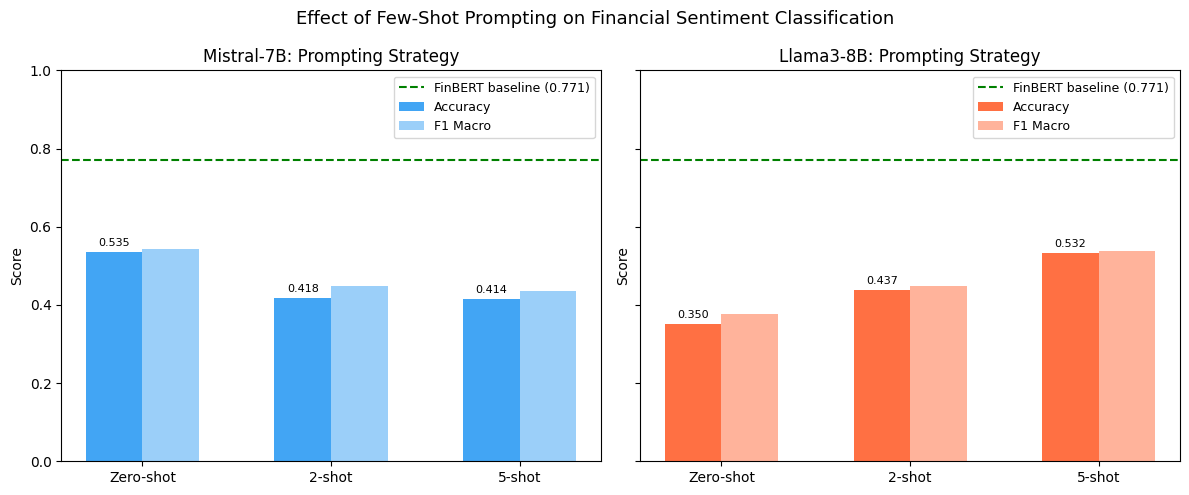

Figure saved.


In [11]:
import matplotlib.pyplot as plt
import numpy as np

df_res = pd.read_csv("fewshot_evaluation.csv")

mistral_rows = df_res[df_res["Model"].str.contains("Mistral")].reset_index(drop=True)
llama_rows   = df_res[df_res["Model"].str.contains("Llama")].reset_index(drop=True)
finbert_acc  = df_res.loc[df_res["Model"]=="FinBERT (zero-shot)", "Accuracy"].values[0]

x = np.arange(3)
w = 0.3
labels = ["Zero-shot", "2-shot", "5-shot"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, model_rows, title, color in [
    (axes[0], mistral_rows, "Mistral-7B", "#2196F3"),
    (axes[1], llama_rows,   "Llama3-8B",  "#FF5722")
]:
    acc_vals = model_rows["Accuracy"].tolist()
    f1_vals  = model_rows["F1_macro"].tolist()
    
    bars1 = ax.bar(x - w/2, acc_vals, w, label="Accuracy", color=color, alpha=0.85)
    bars2 = ax.bar(x + w/2, f1_vals,  w, label="F1 Macro", color=color, alpha=0.45)
    
    ax.axhline(finbert_acc, color="green", linestyle="--", linewidth=1.5,
               label=f"FinBERT baseline ({finbert_acc:.3f})")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"{title}: Prompting Strategy", fontsize=12)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)
    
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

plt.suptitle("Effect of Few-Shot Prompting on Financial Sentiment Classification", fontsize=13)
plt.tight_layout()
plt.savefig("fig_fewshot_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig("fig_fewshot_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved.")

# Cell 12 — Figure: Neutral class F1 across prompting conditions

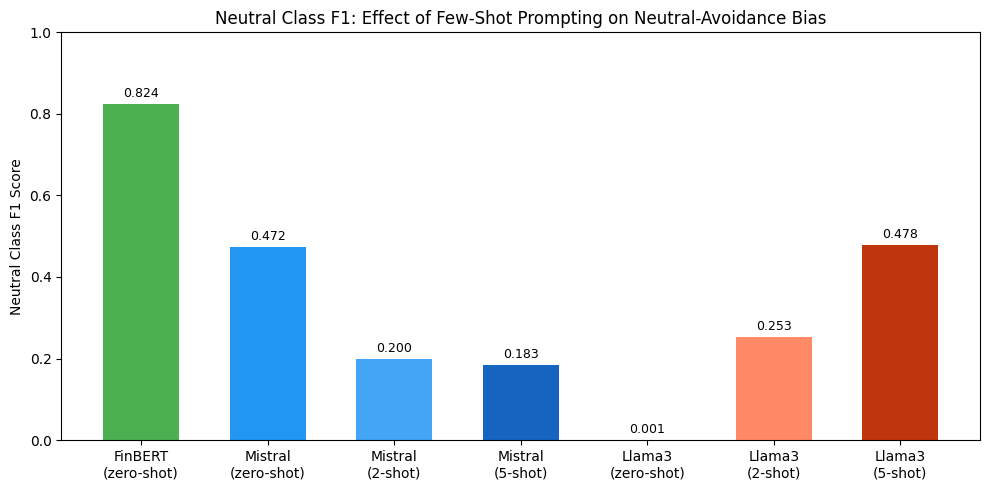

Neutral F1 figure saved.


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

true = df["label"].tolist()

def neutral_f1(pred_col):
    pred = df[pred_col].tolist()
    per_class = f1_score(true, pred, average=None, labels=["negative","neutral","positive"])
    return per_class[1]  

neutral_f1_vals = {
    "FinBERT\n(zero-shot)": neutral_f1("finbert_pred"),
    "Mistral\n(zero-shot)": neutral_f1("mistral_pred"),
    "Mistral\n(2-shot)":    neutral_f1("mistral_2shot_pred"),
    "Mistral\n(5-shot)":    neutral_f1("mistral_5shot_pred"),
    "Llama3\n(zero-shot)": neutral_f1("llama3_pred"),
    "Llama3\n(2-shot)":    neutral_f1("llama3_2shot_pred"),
    "Llama3\n(5-shot)":    neutral_f1("llama3_5shot_pred"),
}

colors = ["#4CAF50","#2196F3","#42A5F5","#1565C0","#FF5722","#FF8A65","#BF360C"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(neutral_f1_vals.keys(), neutral_f1_vals.values(), color=colors, width=0.6)
ax.set_ylabel("Neutral Class F1 Score")
ax.set_title("Neutral Class F1: Effect of Few-Shot Prompting on Neutral-Avoidance Bias")
ax.set_ylim(0, 1.0)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("fig_neutral_f1_fewshot.pdf", dpi=300, bbox_inches='tight')
plt.savefig("fig_neutral_f1_fewshot.png", dpi=300, bbox_inches='tight')
plt.show()
print("Neutral F1 figure saved.")

# Cell 13 — McNemar tests: few-shot vs zero-shot for each model

In [13]:
from statsmodels.stats.contingency_tables import mcnemar

true_arr = np.array(true)

def mcnemar_pair(pred_col_a, pred_col_b):
    a = np.array(df[pred_col_a].tolist())
    b = np.array(df[pred_col_b].tolist())
    correct_a = (a == true_arr)
    correct_b = (b == true_arr)
    n_10 = ((correct_a) & (~correct_b)).sum()  
    n_01 = ((~correct_a) & (correct_b)).sum()  
    table = [[0, n_10], [n_01, 0]]
    result = mcnemar(table, exact=False, correction=True)
    return result.pvalue

tests = [
    ("Mistral 0-shot vs 2-shot", "mistral_pred",       "mistral_2shot_pred"),
    ("Mistral 0-shot vs 5-shot", "mistral_pred",       "mistral_5shot_pred"),
    ("Mistral 2-shot vs 5-shot", "mistral_2shot_pred", "mistral_5shot_pred"),
    ("Llama3 0-shot vs 2-shot",  "llama3_pred",        "llama3_2shot_pred"),
    ("Llama3 0-shot vs 5-shot",  "llama3_pred",        "llama3_5shot_pred"),
    ("Llama3 2-shot vs 5-shot",  "llama3_2shot_pred",  "llama3_5shot_pred"),
]

print(f"{'Comparison':<35} {'p-value':<12} {'Significant?'}")
print("-" * 60)
for label, col_a, col_b in tests:
    p = mcnemar_pair(col_a, col_b)
    sig = "YES (p<0.05)" if p < 0.05 else "NO"
    print(f"{label:<35} {p:<12.4f} {sig}")

Comparison                          p-value      Significant?
------------------------------------------------------------
Mistral 0-shot vs 2-shot            0.0000       YES (p<0.05)
Mistral 0-shot vs 5-shot            0.0000       YES (p<0.05)
Mistral 2-shot vs 5-shot            0.1650       NO
Llama3 0-shot vs 2-shot             0.0000       YES (p<0.05)
Llama3 0-shot vs 5-shot             0.0000       YES (p<0.05)
Llama3 2-shot vs 5-shot             0.0000       YES (p<0.05)


# Cell 14 — Final summary table

In [14]:
df_res = pd.read_csv("fewshot_evaluation.csv")

df_display = df_res.copy()
for col in ["Accuracy","F1_macro","F1_weighted","Acc_PhraseBank","Acc_Twitter"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}")

print("\n=== FULL RESULTS TABLE ===")
print(df_display.to_string(index=False))
df_display.to_csv("fewshot_table_paper.csv", index=False)
print("\nSaved: fewshot_table_paper.csv")


=== FULL RESULTS TABLE ===
                 Model Accuracy F1_macro F1_weighted Acc_PhraseBank Acc_Twitter
   FinBERT (zero-shot)   0.7712   0.7373      0.7769         0.8890      0.7113
Mistral-7B (zero-shot)   0.5347   0.5419      0.5148         0.6471      0.4775
   Mistral-7B (2-shot)   0.4179   0.4493      0.3309         0.4684      0.3921
   Mistral-7B (5-shot)   0.4145   0.4354      0.3181         0.4572      0.3927
 Llama3-8B (zero-shot)   0.3502   0.3768      0.2003         0.3932      0.3283
    Llama3-8B (2-shot)   0.4373   0.4477      0.3607         0.5560      0.3768
    Llama3-8B (5-shot)   0.5319   0.5386      0.5150         0.6985      0.4471

Saved: fewshot_table_paper.csv
